
# How many people have ever lived? A Bayesian prior-predictive model

**Method.** We use the standard three-input-class demographic accounting identity
(Fucks/Winkler/Keyfitz; Population Reference Bureau):

$$
\text{Total ever born} = P_{\text{start}} + \sum_{i} \text{CBR}_i \cdot \bar{P}_i \cdot \Delta t_i
$$

where for each historical interval $i$: $\text{CBR}_i$ is the crude birth rate
(births per 1,000 people per year), $\bar{P}_i$ is the average population during
the interval, and $\Delta t_i$ is its duration in years. $P_\text{start}$ is the
founding population at the start date, which is already "born" and must be
added once rather than derived from a birth rate.

**Why this is a prior-predictive simulation, not posterior inference.** There is
no observed data being conditioned on here — we are not updating beliefs against
a likelihood, we are *propagating* uncertainty in the inputs through a fixed,
known formula to get a distribution over the output. That is exactly what
`pm.sample_prior_predictive()` is for. Running `pm.sample()` (NUTS) on this model
would technically work but would be pointless — there is no likelihood term, so
the "posterior" would just be the prior, sampled far less efficiently than
direct forward simulation. This distinction also resolves the frequentist/Bayesian
question from before: there is no natural repeated-sampling frame for a
one-off historical quantity like this, so a *credible interval* built by
propagating explicit, stated prior uncertainty is the more coherent object than
a *confidence interval*.

**What's new in this version — four structural refinements, applied uniformly
across all three prior-family variants (log-normal / Beta-ish / hybrid), so the
remaining differences between them are purely about prior *shape*, not model
structure:**

1. **Birth-rate trajectory, not a single constant per interval.** Crude birth
   rate now has its own uncertain value at each of the 13 anchor points (a
   `CBR_ANCHORS` table, parallel to the population `ANCHORS`), and the birth
   rate used within an interval is the average of its two endpoints — a
   piecewise-linear trajectory instead of an abrupt step function that was
   flat across spans as long as ~180,000 years.
2. **A stochastic shock ("jump") component for plagues and famines.** Rather
   than assuming population moves smoothly (log-linearly) between anchors, each
   interval gets an optional random mortality shock — a `Bernoulli` "did a
   major shock happen" switch times a `Beta`-shaped magnitude — that
   temporarily depresses the *average* population used for that interval's
   births, without changing the anchor endpoints themselves. Shock
   probabilities and magnitudes are set per interval based on well-known
   historical events (Antonine Plague, Black Death, 1918 flu + WWI/WWII,
   COVID-19, etc.) — see `SHOCKS` below.
3. **Best-attested anchors are now constants, not random variables.** The 2024
   CE population is treated as a known, fixed number (`family="constant"`)
   rather than an uncertain quantity — it's about as well measured as anything
   in this model, so giving it a prior would be manufacturing uncertainty that
   isn't really there. This applies identically in every model variant: a
   `"constant"` designation is an assertion of real-world certainty, not a
   prior-shape preference, so it is never overridden by the global log-normal
   or Beta-ish setting.
4. **The truncated log-normal is now exactly calibrated.** Previously, capping
   a log-normal at an upper bound quietly pulled its *realized* mean below the
   nominal target (removing the right tail removes some of the highest values,
   which were pulling the mean up). This version numerically solves for the
   `mu` that makes the **post-truncation** mean match the target exactly
   (via root-finding — see Section 2), so "truncated log-normal with mean X"
   now actually has mean X.

**The three input classes, each of which can take any of three prior families:**

1. **Starting date** for anatomically modern humans (~190,000–200,000 BCE)
2. **Population size** at a series of historical anchor points
3. **Crude birth rate (CBR)**, now itself a trajectory over the same anchor points

**Three prior families:**

- **Log-normal** — supported on $(0, \infty)$, right-skewed, no upper bound.
  Standard choice for a positive quantity you know "to within a multiplicative
  factor." Its cost: it always assigns *some* probability, however small, to
  values arbitrarily far above your stated range — which can matter a lot once
  you multiply and sum many of these together. Appropriate when the "bound"
  you'd otherwise state is really just current best belief and the field has
  been wrong about it before (paradigm-shift risk, not parameter noise).
- **"Beta-ish"** — meaning a `Beta(α, β)` distribution *affinely rescaled* onto a
  hard-bounded interval `[low, high]` you choose from domain knowledge (e.g., a
  population can't plausibly have exceeded some historical carrying-capacity
  ceiling). We parameterize it by a target **mean** and a **concentration**
  parameter `κ` (higher = more tightly clustered around the mean), then convert
  to the corresponding `(α, β)`. Unlike log-normal, mass is *strictly zero*
  outside `[low, high]` — appropriate when a real ceiling exists and you
  basically know where it is (e.g. well-attested census-era populations,
  or crude birth rate, which has a genuine biological ceiling).
- **Truncated log-normal** — a log-normal shape with a hard upper `cap` applied
  (`pm.Truncated(pm.LogNormal.dist(...), upper=cap)`), now with the mean
  correction described above. This is the useful middle ground: you want
  log-normal's realistic multiplicative/skewed shape, but you do have one
  piece of information you're not willing to violate (e.g. "population at
  3000 BCE definitely didn't exceed 35 million — that's archaeologically
  indefensible — but I'm not ready to commit to a symmetric bounded shape
  either").

**Hybrid, canonical model.** Rather than force one family onto every parameter,
the model built below assigns a family **per parameter**, based on how well
each period of history is actually attested:

| Period | Population | Birth rate | Family | Why |
|---|---|---|---|---|
| Founding / start date | ✓ | — | Log-normal | Deep prehistory, genuinely open-ended — origin dates have shifted by 140,000 years within living memory of the field |
| Founding → 8,000 BCE | — | ✓ | Log-normal | Same reasoning: earliest, most speculative era |
| 8,000 BCE, 3,000 BCE | ✓ | ✓ | Truncated log-normal | Archaeological carrying-capacity estimates: skewed uncertainty, but a defensible ceiling exists |
| 1 CE – 2000 CE | ✓ | ✓ | Beta-ish | Written records, censuses, vital statistics — real bounds, well known |
| 2024 CE population | ✓ | — | **Constant** | Best-attested value in the whole model — treated as known |

This hybrid is the **canonical model going forward** — the pure log-normal and
pure Beta-ish models are kept below only as a reference/sensitivity check, not
as ongoing alternatives to maintain.

Everything numeric below (population anchors, birth rates, shock probabilities
and magnitudes) is an **illustrative starting point** loosely patterned on
commonly-cited historical population reconstructions (e.g. McEvedy & Jones'
*Atlas of World Population History*, UN World Population Prospects, and the
PRB/Haub lineage) and well-known historical mortality events — not a
literature-vetted set of point estimates. Swap in your own researched values
before treating the output as more than a worked methodological example.


In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm

%matplotlib inline

print("PyMC version:", pm.__version__)
assert pm.__version__.startswith("6."), "This notebook targets the PyMC 6.x API (written/tested against 6.3.1)."

RNG_SEED = 20240826
N_PRIOR_SAMPLES = 20_000

Matplotlib is building the font cache; this may take a moment.


PyMC version: 6.3.1



## 1. Input data: population anchors, birth-rate trajectory, and shocks

Three parallel tables now define the model:

- **`ANCHORS`** — population at 13 points in time. `ANCHORS[0]` is the founding
  population at the (uncertain) start date — its `year` is `None` because the
  start date is itself a random variable, handled separately. The last entry
  (2024 CE) is `family="constant"`.
- **`CBR_ANCHORS`** — crude birth rate at the *same* 13 points in time (the
  trajectory control points). The birth rate used within interval `j` is the
  average of `CBR_ANCHORS[j]` and `CBR_ANCHORS[j+1]`.
- **`SHOCKS`** — one entry per interval (12 total) giving a shock probability
  and a plausible fractional-population-loss range, used to build the
  stochastic mortality-shock component. These are illustrative magnitudes
  loosely anchored to well-known historical events (noted in each `note`
  field), not literature-derived point estimates.

Every `ANCHORS`/`CBR_ANCHORS` entry carries a `family` field (and `cap` where
relevant) used **only** by the hybrid model, *except* `family="constant"`,
which always applies regardless of which model variant is being built. The
pure log-normal and pure Beta-ish models ignore the other `family` values and
apply their single global family to every non-constant parameter.


In [2]:
ANCHORS = [
    dict(label="start_founding",   year=None,   pop_mean=1.0e4,  pop_low=1.0e3,  pop_high=1.0e5,
         family="lognormal"),
    dict(label="8000BCE_agri",     year=-8000,  pop_mean=5.0e6,  pop_low=1.0e6,  pop_high=1.0e7,
         family="truncated_lognormal", cap=1.5e7),
    dict(label="3000BCE_bronze",   year=-3000,  pop_mean=1.4e7,  pop_low=1.0e7,  pop_high=2.0e7,
         family="truncated_lognormal", cap=3.5e7),
    dict(label="1CE",              year=1,      pop_mean=3.0e8,  pop_low=1.7e8,  pop_high=4.0e8,
         family="beta"),
    dict(label="1000CE",           year=1000,   pop_mean=3.1e8,  pop_low=2.65e8, pop_high=3.45e8,
         family="beta"),
    dict(label="1500CE",           year=1500,   pop_mean=5.0e8,  pop_low=4.25e8, pop_high=5.4e8,
         family="beta"),
    dict(label="1650CE",           year=1650,   pop_mean=5.5e8,  pop_low=4.7e8,  pop_high=6.0e8,
         family="beta"),
    dict(label="1750CE",           year=1750,   pop_mean=8.0e8,  pop_low=7.2e8,  pop_high=9.5e8,
         family="beta"),
    dict(label="1850CE",           year=1850,   pop_mean=1.26e9, pop_low=1.20e9, pop_high=1.30e9,
         family="beta"),
    dict(label="1900CE",           year=1900,   pop_mean=1.65e9, pop_low=1.60e9, pop_high=1.70e9,
         family="beta"),
    dict(label="1950CE",           year=1950,   pop_mean=2.50e9, pop_low=2.45e9, pop_high=2.55e9,
         family="beta"),
    dict(label="2000CE",           year=2000,   pop_mean=6.10e9, pop_low=6.00e9, pop_high=6.20e9,
         family="beta"),
    dict(label="2024CE",           year=2024,   pop_mean=8.10e9, pop_low=8.00e9, pop_high=8.20e9,
         family="constant"),   # best-attested anchor in the model: treated as known
]

CBR_ANCHORS = [
    dict(label="start_founding", cbr_mean=85, cbr_low=65, cbr_high=98, family="lognormal"),
    dict(label="8000BCE_agri",   cbr_mean=75, cbr_low=60, cbr_high=90, family="truncated_lognormal", cap=98),
    dict(label="3000BCE_bronze", cbr_mean=65, cbr_low=50, cbr_high=80, family="truncated_lognormal", cap=92),
    dict(label="1CE",            cbr_mean=58, cbr_low=45, cbr_high=70, family="beta"),
    dict(label="1000CE",         cbr_mean=55, cbr_low=42, cbr_high=68, family="beta"),
    dict(label="1500CE",         cbr_mean=52, cbr_low=40, cbr_high=63, family="beta"),
    dict(label="1650CE",         cbr_mean=48, cbr_low=36, cbr_high=58, family="beta"),
    dict(label="1750CE",         cbr_mean=43, cbr_low=33, cbr_high=52, family="beta"),
    dict(label="1850CE",         cbr_mean=40, cbr_low=32, cbr_high=47, family="beta"),
    dict(label="1900CE",         cbr_mean=35, cbr_low=29, cbr_high=42, family="beta"),
    dict(label="1950CE",         cbr_mean=30, cbr_low=24, cbr_high=37, family="beta"),
    dict(label="2000CE",         cbr_mean=22, cbr_low=18, cbr_high=27, family="beta"),
    dict(label="2024CE",         cbr_mean=18, cbr_low=16, cbr_high=20, family="beta"),
]

assert len(CBR_ANCHORS) == len(ANCHORS)

SHOCKS = [
    dict(note="deep-prehistory famine / local-collapse risk",  shock_prob=0.30, loss_low=0.05, loss_high=0.25),  # founding -> 8000 BCE
    dict(note="early-agricultural crop-failure risk",          shock_prob=0.25, loss_low=0.03, loss_high=0.15),  # 8000 -> 3000 BCE
    dict(note="e.g. Bronze Age Collapse (~1200 BCE)",          shock_prob=0.20, loss_low=0.03, loss_high=0.12),  # 3000 BCE -> 1 CE
    dict(note="e.g. Antonine Plague, Plague of Justinian",     shock_prob=0.60, loss_low=0.03, loss_high=0.15),  # 1 -> 1000 CE
    dict(note="Black Death (1347-1351)",                       shock_prob=0.85, loss_low=0.08, loss_high=0.25),  # 1000 -> 1500 CE
    dict(note="Columbian Exchange population collapse",        shock_prob=0.40, loss_low=0.03, loss_high=0.15),  # 1500 -> 1650 CE
    dict(note="regional wars/famines",                         shock_prob=0.15, loss_low=0.02, loss_high=0.08),  # 1650 -> 1750 CE
    dict(note="Napoleonic wars, regional famines",             shock_prob=0.15, loss_low=0.02, loss_high=0.06),  # 1750 -> 1850 CE
    dict(note="19th-c. famines (e.g. 1876-79 China)",          shock_prob=0.20, loss_low=0.01, loss_high=0.05),  # 1850 -> 1900 CE
    dict(note="WWI, 1918 flu, WWII",                           shock_prob=0.70, loss_low=0.02, loss_high=0.08),  # 1900 -> 1950 CE
    dict(note="e.g. Great Leap Forward famine",                shock_prob=0.10, loss_low=0.005, loss_high=0.02), # 1950 -> 2000 CE
    dict(note="e.g. COVID-19 pandemic",                        shock_prob=0.15, loss_low=0.002, loss_high=0.01), # 2000 -> 2024 CE
]

assert len(SHOCKS) == len(ANCHORS) - 1

# Audit tables: always visible and easy to double-check, not buried in code.
pop_cbr_audit = pd.DataFrame([
    dict(anchor=a["label"], pop_family=a["family"], pop_cap=a.get("cap", ""),
         cbr_family=c["family"], cbr_cap=c.get("cap", ""))
    for a, c in zip(ANCHORS, CBR_ANCHORS)
])
shock_audit = pd.DataFrame([
    dict(interval=f"{ANCHORS[j]['label']} -> {ANCHORS[j+1]['label']}", **s)
    for j, s in enumerate(SHOCKS)
])

pop_cbr_audit

,anchor,pop_family,pop_cap,cbr_family,cbr_cap
0,start_founding,lognormal,,lognormal,
1,8000BCE_agri,truncated_lognormal,15000000.0,truncated_lognormal,98
2,3000BCE_bronze,truncated_lognormal,35000000.0,truncated_lognormal,92
3,1CE,beta,,beta,
4,1000CE,beta,,beta,
5,1500CE,beta,,beta,
6,1650CE,beta,,beta,
7,1750CE,beta,,beta,
8,1850CE,beta,,beta,
9,1900CE,beta,,beta,


In [3]:
shock_audit

,interval,note,shock_prob,loss_low,loss_high
0,start_founding -> 8000BCE_agri,deep-prehistory famine / local-collapse risk,0.30,0.050,0.25
1,8000BCE_agri -> 3000BCE_bronze,early-agricultural crop-failure risk,0.25,0.030,0.15
2,3000BCE_bronze -> 1CE,e.g. Bronze Age Collapse (~1200 BCE),0.20,0.030,0.12
3,1CE -> 1000CE,"e.g. Antonine Plague, Plague of Justinian",0.60,0.030,0.15
4,1000CE -> 1500CE,Black Death (1347-1351),0.85,0.080,0.25
5,1500CE -> 1650CE,Columbian Exchange population collapse,0.40,0.030,0.15
6,1650CE -> 1750CE,regional wars/famines,0.15,0.020,0.08
7,1750CE -> 1850CE,"Napoleonic wars, regional famines",0.15,0.020,0.06
8,1850CE -> 1900CE,19th-c. famines (e.g. 1876-79 China),0.20,0.010,0.05
9,1900CE -> 1950CE,"WWI, 1918 flu, WWII",0.70,0.020,0.08



## 2. Prior-parameterization helpers

`lognormal_params` and `betaish_params` take a **mean** and a **[low, high]
range** and return the distribution parameters that reproduce that mean with
that spread. `corrected_truncated_lognormal_params` does the same for a
log-normal that will subsequently be capped at `cap` — but it numerically
solves for the `mu` that makes the **post-truncation** mean equal the target,
rather than the pre-truncation mean (which is what naively reusing
`lognormal_params` would calibrate).

**Why a correction is needed.** If $X \sim \text{LogNormal}(\mu, \sigma^2)$
truncated to $X \le b$, its mean is

$$
E[X \mid X \le b] = e^{\mu + \sigma^2/2} \cdot \frac{\Phi\!\left(\frac{\ln b - \mu}{\sigma} - \sigma\right)}{\Phi\!\left(\frac{\ln b - \mu}{\sigma}\right)}
$$

which is strictly *less* than the untruncated mean $e^{\mu+\sigma^2/2}$ — cutting
off the right tail removes exactly the values that were pulling the mean up.
`corrected_truncated_lognormal_params` holds $\sigma$ fixed (from the stated
`[low, high]` range) and root-finds for the $\mu$ that makes this expression
equal the target mean exactly, via `scipy.optimize.brentq`. If the search fails
(only possible if `cap` is too close to `mean` to be achievable at all with any
$\mu$), it falls back to the naive calibration and prints a warning rather than
crashing.


In [4]:
def lognormal_params(mean, low, high, z=1.96):
    '''(mu, sigma) for a LogNormal with the given arithmetic mean, calibrated
    so that [low, high] corresponds to roughly a central (1 - 2*Phi(-z)) interval
    (z=1.96 -> ~95%, z=1.645 -> ~90% one-sided).'''
    sigma = (np.log(high) - np.log(low)) / (2 * z)
    mu = np.log(mean) - 0.5 * sigma**2
    return mu, sigma


def betaish_params(mean, low, high, kappa=8.0):
    '''(alpha, beta) for a Beta distribution such that, after rescaling via
    low + (high - low) * Beta(alpha, beta), the result has the given mean and
    is supported ONLY on [low, high]. kappa = alpha + beta controls how tightly
    mass clusters around the mean (higher kappa -> narrower, more peaked).'''
    p = (mean - low) / (high - low)
    assert 0 < p < 1, "mean must lie strictly inside [low, high]"
    alpha = p * kappa
    beta_ = (1 - p) * kappa
    return alpha, beta_


def _truncated_lognormal_mean(mu, sigma, cap):
    '''Analytic mean of LogNormal(mu, sigma) truncated to [0, cap].'''
    zc = (np.log(cap) - mu) / sigma
    num = norm.cdf(zc - sigma)
    den = norm.cdf(zc)
    if den < 1e-300:
        return np.inf
    return np.exp(mu + sigma**2 / 2.0) * num / den


def corrected_truncated_lognormal_params(mean, low, high, cap, z=1.96, name=""):
    '''Like lognormal_params, but solves for mu (holding sigma fixed at the
    value implied by [low, high]) so that the MEAN AFTER TRUNCATION at `cap`
    equals `mean` exactly -- correcting for the mass removed by the cap.'''
    _, sigma = lognormal_params(mean, low, high, z=z)
    mu_naive = np.log(mean) - 0.5 * sigma**2

    def f(mu):
        return _truncated_lognormal_mean(mu, sigma, cap) - mean

    mu_lo, mu_hi = mu_naive - 10 * sigma, mu_naive + 10 * sigma
    tries = 0
    while f(mu_lo) > 0 and tries < 50:
        mu_lo -= 2 * sigma
        tries += 1
    tries = 0
    while f(mu_hi) < 0 and tries < 50:
        mu_hi += 2 * sigma
        tries += 1
    try:
        mu_star = brentq(f, mu_lo, mu_hi)
        return mu_star, sigma
    except (ValueError, RuntimeError) as e:
        print(f"WARNING: truncation-mean correction failed for {name!r} ({e}); "
              f"falling back to the uncorrected (nominal) mu. Consider raising `cap`.")
        return mu_naive, sigma

In [5]:
# Quick sanity check of the correction, reproducing the validation done before
# committing to this approach: naive calibration undershoots the target mean
# once truncated; the corrected version hits it exactly.
_mean, _low, _high, _cap = 5.0e6, 1.0e6, 1.0e7, 1.5e7
_mu_naive, _sigma = lognormal_params(_mean, _low, _high)
_mu_corr, _ = corrected_truncated_lognormal_params(_mean, _low, _high, _cap, name="sanity_check")

print(f"Naive mu     -> truncated mean = {_truncated_lognormal_mean(_mu_naive, _sigma, _cap):,.0f}  (target {_mean:,.0f})")
print(f"Corrected mu -> truncated mean = {_truncated_lognormal_mean(_mu_corr, _sigma, _cap):,.0f}  (target {_mean:,.0f})")

Naive mu     -> truncated mean = 4,785,686  (target 5,000,000)
Corrected mu -> truncated mean = 5,000,000  (target 5,000,000)



## 3. Building the model

`build_model(prior_family, kappa)` constructs the full PyMC model. It supports
three values of `prior_family`:

- `"lognormal"` — every non-constant parameter gets an (open-tailed) log-normal prior.
- `"beta"` — every non-constant parameter gets a hard-bounded Beta-ish prior.
- `"hybrid"` — **the canonical model.** Each parameter reads its own `family`
  (and `cap`, if any) from the `ANCHORS`/`CBR_ANCHORS` tables defined above.

`resolve_family_and_cap` decides which family actually applies to a given
item: a `"constant"` designation always wins (real-world certainty overrides
any prior-shape setting), otherwise the hybrid model uses the item's own
`family`, and the pure log-normal/Beta-ish models use their single global
setting. The shock component (Section 1's `SHOCKS` table) applies identically
in **all three** model variants — it's a structural feature of the population
trajectory, not a prior-shape choice.

A few modeling notes:

- **Start date.** Under `"lognormal"` and `"hybrid"`, we model
  `extra_years_before_190kya` — how much earlier than 190,000 BCE the true
  origin might be — as LogNormal with a long right tail (open-ended, since
  origin-date estimates have shifted by well over 100,000 years within the
  field's living memory). Under pure `"beta"`, 190,000–200,000 BCE is instead
  a hard bound with zero probability outside it.
- **Birth-rate trajectory.** `avg_cbr` for interval `j` is the arithmetic mean
  of the CBR trajectory's two endpoints, `CBR_ANCHORS[j]` and
  `CBR_ANCHORS[j+1]` — a simple linear interpolation. (Unlike population,
  birth rate isn't a compounding quantity, so an arithmetic mean of the
  endpoints is the natural choice here, rather than the logarithmic mean used
  for population.)
- **Population path.** The *smooth* average population per interval is still
  the logarithmic mean $(P_b - P_a)/(\ln P_b - \ln P_a)$ appropriate for
  exponential growth between two fixed anchors — falling back to the
  arithmetic mean when $P_a \approx P_b$ to avoid a 0/0.
- **Shock component.** For each interval, `has_shock ~ Bernoulli(shock_prob)`
  and `shock_loss ~` a Beta-ish fraction on `[loss_low, loss_high]`; the
  *effective* average population used for that interval's births is
  `avg_pop_smooth * (1 - has_shock * shock_loss)`. This models a temporary
  mortality-driven dip in the path between two anchors without altering the
  anchors themselves — anchors remain the "ground truth" endpoints; only the
  shape of the path between them becomes stochastic.
- **Total.** `total_ever_born = founding population + sum of interval births`.
  Consistent with the demographic literature, this does **not** depend on
  death rates directly — mortality only enters through the shock component's
  effect on *average population during births*, which is a modeling
  convenience for capturing known catastrophes, not a full mortality model.


In [6]:
def logarithmic_mean(p_a, p_b):
    diff = p_b - p_a
    logdiff = pm.math.log(p_b) - pm.math.log(p_a)
    return pm.math.switch(pt.abs(diff) < 1.0, (p_a + p_b) / 2.0, diff / logdiff)


def make_bounded_positive_prior(name, family, mean, low, high, kappa=8.0, z=1.96, cap=None):
    '''Build a single positive-valued PyMC prior in one of four families:
      - "lognormal": open right tail, calibrated from (mean, low, high)
      - "beta": hard-bounded on [low, high] via a rescaled Beta ("Beta-ish")
      - "truncated_lognormal": lognormal shape, hard-capped at `cap`, with the
        mean-after-truncation correction from Section 2
      - "constant": fixed at `mean`, no uncertainty at all
    Returns a pytensor variable for the quantity itself, on its natural scale.'''
    if family == "lognormal":
        mu, sigma = lognormal_params(mean, low, high, z=z)
        return pm.LogNormal(name, mu=mu, sigma=sigma)
    elif family == "truncated_lognormal":
        assert cap is not None, f"{name}: truncated_lognormal requires a cap"
        mu, sigma = corrected_truncated_lognormal_params(mean, low, high, cap, z=z, name=name)
        return pm.Truncated(name, pm.LogNormal.dist(mu=mu, sigma=sigma), upper=cap)
    elif family == "beta":
        alpha, beta_ = betaish_params(mean, low, high, kappa=kappa)
        frac = pm.Beta(name + "_frac", alpha=alpha, beta=beta_)
        return pm.Deterministic(name, low + frac * (high - low))
    elif family == "constant":
        return pm.Deterministic(name, pt.as_tensor_variable(float(mean)))
    else:
        raise ValueError(f"unknown prior family: {family!r}")


def resolve_family_and_cap(item, prior_family):
    '''Decide which prior family (and cap, if any) actually applies to one
    anchor / CBR-control-point, given the model's global `prior_family`. A
    "constant" designation always wins in every model variant -- it asserts
    real-world certainty, not a prior-shape preference, so the global
    lognormal/beta setting never overrides it.'''
    if item["family"] == "constant":
        return "constant", None
    if prior_family == "hybrid":
        return item["family"], item.get("cap")
    return prior_family, None


def build_model(prior_family="hybrid", kappa=8.0, z=1.96):
    assert prior_family in ("lognormal", "beta", "hybrid")

    with pm.Model() as model:

        # ---- Input class 1: starting date -----------------------------------
        if prior_family == "beta":
            a_s, b_s = betaish_params(mean=195_000, low=190_000, high=200_000, kappa=kappa)
            start_frac = pm.Beta("start_frac", alpha=a_s, beta=b_s)
            start_year = pm.Deterministic("start_year", -200_000 + start_frac * 10_000)
        else:  # "lognormal" and "hybrid" both use the open-tailed start date
            mu_e, sigma_e = lognormal_params(mean=5000, low=200, high=10000, z=1.645)
            extra_years = pm.LogNormal("extra_years_before_190kya", mu=mu_e, sigma=sigma_e)
            start_year = pm.Deterministic("start_year", -190_000 - extra_years)

        # ---- Input class 2: population at each anchor -----------------------
        pops = []
        for i, a in enumerate(ANCHORS):
            name = f"pop_{i}_{a['label']}"
            family, cap = resolve_family_and_cap(a, prior_family)
            p_i = make_bounded_positive_prior(
                name, family, a["pop_mean"], a["pop_low"], a["pop_high"], kappa=kappa, z=z, cap=cap
            )
            pops.append(p_i)

        # ---- Input class 3: birth-rate TRAJECTORY (one value per anchor) ----
        cbrs = []
        for i, c in enumerate(CBR_ANCHORS):
            name = f"cbr_{i}_{c['label']}"
            family, cap = resolve_family_and_cap(c, prior_family)
            c_i = make_bounded_positive_prior(
                name, family, c["cbr_mean"], c["cbr_low"], c["cbr_high"], kappa=kappa, z=z, cap=cap
            )
            cbrs.append(c_i)

        # ---- Interval-by-interval births, with a stochastic shock component -
        births_list = []
        for j, shock in enumerate(SHOCKS):
            p_a, p_b = pops[j], pops[j + 1]
            year_a = start_year if j == 0 else ANCHORS[j]["year"]
            year_b = ANCHORS[j + 1]["year"]
            duration = year_b - year_a

            avg_cbr = pm.Deterministic(f"avg_cbr_{j}", (cbrs[j] + cbrs[j + 1]) / 2.0)
            avg_pop_smooth = logarithmic_mean(p_a, p_b)

            al, be = betaish_params(
                mean=(shock["loss_low"] + shock["loss_high"]) / 2.0,
                low=shock["loss_low"], high=shock["loss_high"], kappa=4.0,
            )
            shock_magfrac = pm.Beta(f"shock_magfrac_{j}", alpha=al, beta=be)
            shock_magnitude = pm.Deterministic(
                f"shock_loss_{j}", shock["loss_low"] + shock_magfrac * (shock["loss_high"] - shock["loss_low"])
            )
            has_shock = pm.Bernoulli(f"has_shock_{j}", p=shock["shock_prob"])
            effective_loss = pm.Deterministic(f"effective_shock_loss_{j}", has_shock * shock_magnitude)
            avg_pop_effective = pm.Deterministic(f"avg_pop_{j}", avg_pop_smooth * (1.0 - effective_loss))

            births_j = pm.Deterministic(f"births_{j}", (avg_cbr / 1000.0) * avg_pop_effective * duration)
            births_list.append(births_j)

        total_births = pm.math.sum(pt.stack(births_list))
        total_ever_born = pm.Deterministic("total_ever_born", pops[0] + total_births)
        pct_alive_today = pm.Deterministic(
            "pct_alive_today", 100.0 * pops[-1] / total_ever_born
        )

    return model


## 4. Monte Carlo propagation (prior-predictive sampling)

This is the whole "Monte Carlo propagation" step: draw many independent samples
from all the priors (including the new shock switches and magnitudes), push
each draw through the deterministic accounting formula, and look at the
resulting distribution of `total_ever_born`.


In [7]:
model_lognormal = build_model(prior_family="lognormal")
model_beta = build_model(prior_family="beta", kappa=8.0)
model_hybrid = build_model(prior_family="hybrid", kappa=8.0)

with model_lognormal:
    prior_lognormal = pm.sample_prior_predictive(draws=N_PRIOR_SAMPLES, random_seed=RNG_SEED)

with model_beta:
    prior_beta = pm.sample_prior_predictive(draws=N_PRIOR_SAMPLES, random_seed=RNG_SEED)

with model_hybrid:
    prior_hybrid = pm.sample_prior_predictive(draws=N_PRIOR_SAMPLES, random_seed=RNG_SEED)

totals_ln = prior_lognormal.prior["total_ever_born"].values.flatten()
totals_be = prior_beta.prior["total_ever_born"].values.flatten()
totals_hy = prior_hybrid.prior["total_ever_born"].values.flatten()

pct_alive_ln = prior_lognormal.prior["pct_alive_today"].values.flatten()
pct_alive_be = prior_beta.prior["pct_alive_today"].values.flatten()
pct_alive_hy = prior_hybrid.prior["pct_alive_today"].values.flatten()

print(f"Lognormal draws: {totals_ln.shape[0]:,}   Beta-ish draws: {totals_be.shape[0]:,}   Hybrid draws: {totals_hy.shape[0]:,}")

Sampling: [cbr_0_start_founding, cbr_10_1950CE, cbr_11_2000CE, cbr_12_2024CE, cbr_1_8000BCE_agri, cbr_2_3000BCE_bronze, cbr_3_1CE, cbr_4_1000CE, cbr_5_1500CE, cbr_6_1650CE, cbr_7_1750CE, cbr_8_1850CE, cbr_9_1900CE, extra_years_before_190kya, has_shock_0, has_shock_1, has_shock_10, has_shock_11, has_shock_2, has_shock_3, has_shock_4, has_shock_5, has_shock_6, has_shock_7, has_shock_8, has_shock_9, pop_0_start_founding, pop_10_1950CE, pop_11_2000CE, pop_1_8000BCE_agri, pop_2_3000BCE_bronze, pop_3_1CE, pop_4_1000CE, pop_5_1500CE, pop_6_1650CE, pop_7_1750CE, pop_8_1850CE, pop_9_1900CE, shock_magfrac_0, shock_magfrac_1, shock_magfrac_10, shock_magfrac_11, shock_magfrac_2, shock_magfrac_3, shock_magfrac_4, shock_magfrac_5, shock_magfrac_6, shock_magfrac_7, shock_magfrac_8, shock_magfrac_9]
Sampling: [cbr_0_start_founding_frac, cbr_10_1950CE_frac, cbr_11_2000CE_frac, cbr_12_2024CE_frac, cbr_1_8000BCE_agri_frac, cbr_2_3000BCE_bronze_frac, cbr_3_1CE_frac, cbr_4_1000CE_frac, cbr_5_1500CE_frac, c

Lognormal draws: 20,000   Beta-ish draws: 20,000   Hybrid draws: 20,000



## 5. Summary: credible intervals and comparison


In [8]:
def summarize(samples, label):
    billions = samples / 1e9
    hdi_94 = az.hdi(billions, prob=0.94)
    return {
        "prior family": label,
        "mean (B)": np.mean(billions),
        "median (B)": np.median(billions),
        "sd (B)": np.std(billions),
        "95% CI low (B)": np.percentile(billions, 2.5),
        "95% CI high (B)": np.percentile(billions, 97.5),
        "94% HDI low (B)": hdi_94[0],
        "94% HDI high (B)": hdi_94[1],
    }

summary_df = pd.DataFrame([
    summarize(totals_ln, "Log-normal (all params)"),
    summarize(totals_be, "Beta-ish (all params)"),
    summarize(totals_hy, "Hybrid (canonical)"),
]).set_index("prior family").round(2)

summary_df

,mean (B),median (B),sd (B),95% CI low (B),95% CI high (B),94% HDI low (B),94% HDI high (B)
prior family,,,,,,,
Log-normal (all params),80.90,79.84,8.78,66.87,100.91,65.49,97.03
Beta-ish (all params),81.72,81.58,5.19,71.84,92.06,72.49,91.82
Hybrid (canonical),81.16,80.30,7.16,69.52,97.57,68.38,94.52


In [9]:
pct_alive_df = pd.DataFrame([
    {
        "prior family": "Log-normal (all params)",
        "mean % alive today": np.mean(pct_alive_ln),
        "95% CI low": np.percentile(pct_alive_ln, 2.5),
        "95% CI high": np.percentile(pct_alive_ln, 97.5),
    },
    {
        "prior family": "Beta-ish (all params)",
        "mean % alive today": np.mean(pct_alive_be),
        "95% CI low": np.percentile(pct_alive_be, 2.5),
        "95% CI high": np.percentile(pct_alive_be, 97.5),
    },
    {
        "prior family": "Hybrid (canonical)",
        "mean % alive today": np.mean(pct_alive_hy),
        "95% CI low": np.percentile(pct_alive_hy, 2.5),
        "95% CI high": np.percentile(pct_alive_hy, 97.5),
    },
]).set_index("prior family").round(2)

pct_alive_df

,mean % alive today,95% CI low,95% CI high
prior family,,,
Log-normal (all params),10.12,8.03,12.11
Beta-ish (all params),9.95,8.80,11.28
Hybrid (canonical),10.06,8.30,11.65


In [10]:
# How often does each interval's shock actually "fire" in the hybrid model,
# and roughly how much does it take off the total on average? A quick audit
# of the new stochastic component, not just the headline total.
shock_fire_rates = []
for j, s in enumerate(SHOCKS):
    fired = prior_hybrid.prior[f"has_shock_{j}"].values.flatten()
    loss = prior_hybrid.prior[f"effective_shock_loss_{j}"].values.flatten()
    shock_fire_rates.append({
        "interval": f"{ANCHORS[j]['label']} -> {ANCHORS[j+1]['label']}",
        "nominal shock_prob": s["shock_prob"],
        "observed fire rate": fired.mean(),
        "mean effective loss (all draws)": loss.mean(),
        "mean loss | fired": loss[fired == 1].mean() if fired.sum() > 0 else np.nan,
    })

pd.DataFrame(shock_fire_rates).round(4)

,interval,nominal shock_prob,observed fire rate,mean effective loss (all draws),mean loss | fired
0,start_founding -> 8000BCE_agri,0.30,0.2983,0.0448,0.1502
1,8000BCE_agri -> 3000BCE_bronze,0.25,0.2556,0.0231,0.0904
2,3000BCE_bronze -> 1CE,0.20,0.2000,0.0149,0.0743
3,1CE -> 1000CE,0.60,0.6022,0.0541,0.0899
4,1000CE -> 1500CE,0.85,0.8522,0.1407,0.1651
5,1500CE -> 1650CE,0.40,0.3977,0.0358,0.0900
6,1650CE -> 1750CE,0.15,0.1496,0.0075,0.0501
7,1750CE -> 1850CE,0.15,0.1560,0.0063,0.0401
8,1850CE -> 1900CE,0.20,0.2049,0.0061,0.0300
9,1900CE -> 1950CE,0.70,0.7058,0.0354,0.0501



## 6. Visual comparison


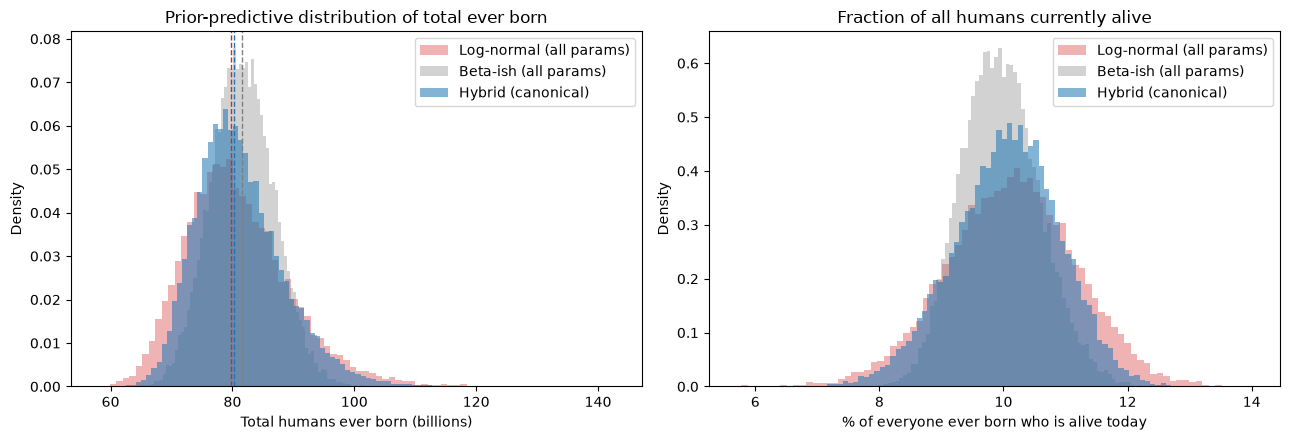

In [27]:
colors = {"ln": "tab:red", "be": "tab:gray", "hy": "tab:blue"}
alphas = {"ln": 0.35, "be": 0.35, "hy": 0.55}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(totals_ln / 1e9, bins=80, alpha=alphas["ln"], label="Log-normal (all params)", color=colors["ln"], density=True)
axes[0].hist(totals_be / 1e9, bins=80, alpha=alphas["be"], label="Beta-ish (all params)", color=colors["be"], density=True)
axes[0].hist(totals_hy / 1e9, bins=80, alpha=alphas["hy"], label="Hybrid (canonical)", color=colors["hy"], density=True)
axes[0].axvline(np.median(totals_ln) / 1e9, color=colors["ln"], linestyle="--", linewidth=1)
axes[0].axvline(np.median(totals_be) / 1e9, color=colors["be"], linestyle="--", linewidth=1)
axes[0].axvline(np.median(totals_hy) / 1e9, color=colors["hy"], linestyle="--", linewidth=1)
axes[0].set_xlabel("Total humans ever born (billions)")
axes[0].set_ylabel("Density")
axes[0].set_title("Prior-predictive distribution of total ever born")
axes[0].legend()

axes[1].hist(pct_alive_ln, bins=80, alpha=alphas["ln"], label="Log-normal (all params)", color=colors["ln"], density=True)
axes[1].hist(pct_alive_be, bins=80, alpha=alphas["be"], label="Beta-ish (all params)", color=colors["be"], density=True)
axes[1].hist(pct_alive_hy, bins=80, alpha=alphas["hy"], label="Hybrid (canonical)", color=colors["hy"], density=True)
axes[1].set_xlabel("% of everyone ever born who is alive today")
axes[1].set_ylabel("Density")
axes[1].set_title("Fraction of all humans currently alive")
axes[1].legend()

plt.tight_layout()
plt.show()


### Where the hybrid model lands

The shock component and birth-rate trajectory now add extra width to **all
three** models equally — that part of the uncertainty is structural, not a
prior-family choice. What still differentiates the three is the shape of
uncertainty on the non-constant, non-shock parameters (start date, population,
birth-rate control points). Log-normal's unbounded upper tail means a Monte
Carlo draw can, purely by chance, combine several simultaneously-high values
(a high founding population *and* a high Paleolithic birth rate *and* an early
start date) with no ceiling stopping it — fattening the upper tail of
`total_ever_born`. The pure Beta-ish model caps every input, so that
compounding is capped too, giving the narrowest interval of the three.

Check `summary_df` above for where the hybrid actually lands — it should fall
between the two pure models, but exactly *where* isn't a foregone conclusion:
it depends on the relative weight of its open-tailed parameters (start date,
founding population, and the deepest CBR/population pairs) versus its
hard-bounded ones (everything 1 CE onward, plus the shock component shared
with all three models). In practice it tends to land closer to the middle of
the two pure models than a naive "5 of ~40 parameters are open-tailed" count
might suggest — the open-tailed parameters sit at the very start of an
18,000-year-plus timespan, so their influence compounds across a large share
of total births, not a small share.



## 7. Illustrating the shape difference directly (starting date)

This plots the two starting-date priors' densities analytically (not from
samples) so the bounded-vs-tailed distinction is visually obvious.


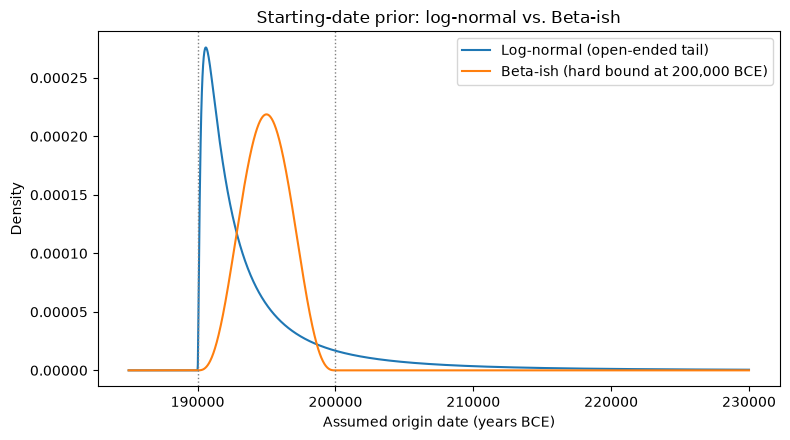

In [12]:
from scipy import stats

years_bce = np.linspace(185_000, 230_000, 2000)

mu_e, sigma_e = lognormal_params(mean=5000, low=200, high=10000, z=1.645)
extra = years_bce - 190_000
ln_density = np.where(
    extra > 0,
    stats.lognorm(s=sigma_e, scale=np.exp(mu_e)).pdf(extra),
    0.0,
)

a_s, b_s = betaish_params(mean=195_000, low=190_000, high=200_000, kappa=8.0)
frac = (years_bce - 190_000) / 10_000
beta_density = np.where(
    (frac >= 0) & (frac <= 1),
    stats.beta(a_s, b_s).pdf(np.clip(frac, 1e-9, 1 - 1e-9)) / 10_000,
    0.0,
)

plt.figure(figsize=(8, 4.5))
plt.plot(years_bce, ln_density, label="Log-normal (open-ended tail)", color="tab:blue")
plt.plot(years_bce, beta_density, label="Beta-ish (hard bound at 200,000 BCE)", color="tab:orange")
plt.axvline(190_000, color="gray", linestyle=":", linewidth=1)
plt.axvline(200_000, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Assumed origin date (years BCE)")
plt.ylabel("Density")
plt.title("Starting-date prior: log-normal vs. Beta-ish")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Takeaways and next steps

- **`model_hybrid` is the canonical model to keep iterating on.** The pure
  log-normal and pure Beta-ish models are retained purely as a one-time
  robustness/sensitivity check ("does the conclusion hinge on this modeling
  choice?"), not as parallel models to maintain going forward.
- **The per-parameter family assignment, the CBR trajectory, and the shock
  configuration are all explicit and auditable** — see the tables printed in
  Section 1. Disagree with a specific choice? Change that one entry in
  `ANCHORS`, `CBR_ANCHORS`, or `SHOCKS` — the model logic doesn't need to
  change.
- **This is still a methodology demonstration, not a finished estimate.**
  Every number in `ANCHORS`, `CBR_ANCHORS`, and `SHOCKS` is an illustrative
  placeholder. Before treating the output as meaningful, replace them with
  values you've actually sourced (McEvedy & Jones, UN WPP, Livi-Bacci, the
  PRB/Haub CBR-by-era table, Kremer 1993, and actual epidemiological/mortality
  estimates for the named historical shocks), and set the ranges to reflect
  real disagreement across sources, not a guessed spread.
- **The shock audit table in Section 5 is worth checking whenever you change
  `SHOCKS`** — it reports each interval's *observed* fire rate and average
  effective loss across the Monte Carlo draws, which is a good way to confirm
  the shock component is doing what you intended before trusting the headline
  interval.
- **The credible interval is only as good as the prior elicitation.** Because
  this is a forward simulation with no data to correct it, there's no
  "learning" step — garbage in, garbage out, with a nice-looking histogram
  around it. The main value of doing it this way over a single point estimate
  is that it forces you to be explicit about *which* uncertainties you think
  matter and by how much, and shows you which inputs actually drive the width
  of the final interval (worth checking via a one-at-a-time sensitivity sweep,
  or by inspecting prior correlations between each input and
  `total_ever_born`).
- **`kappa`, the truncation `cap`s, and the shock probabilities/magnitudes are
  knobs, not laws of nature.** Try a few values of each and see how much the
  hybrid model's final interval moves — that sensitivity is itself
  informative, and worth reporting alongside the headline interval.
- **Further possible extensions:** (1) let shock timing matter — right now a
  shock's effect is a flat discount over the whole interval regardless of
  where in the (possibly very long) interval it occurred; a more careful
  treatment would weight the discount by how much of the interval's total
  births the shock actually affects; (2) correlate shocks across adjacent
  intervals (a catastrophe near an anchor boundary should arguably affect
  both neighboring intervals a little, not just one); (3) treat additional
  well-attested anchors (e.g. 1950 or 2000 CE) as constants too, following the
  same pattern used for 2024 CE.
